In [2]:
from ibl_info.prepare_data_pid import (
    get_congruent_incongruent_intervals,
    get_window,
    get_contrast_intervals,
)
from ibl_info.selective_decomposition import filter_eids
import numpy as np
from brainbox.population.decode import get_spike_counts_in_bins
from one.api import ONE
from brainbox.io.one import SpikeSortingLoader, SessionLoader
from brainbox.ephys_plots import plot_brain_regions
from iblatlas.atlas import AllenAtlas
from brainwidemap import bwm_query, load_good_units, load_trials_and_mask, bwm_units
from brainwidemap.bwm_loading import merge_probes
from brainbox.behavior.training import compute_performance, plot_psychometric, plot_reaction_time
from brainbox.task.trials import find_trial_ids
from brainbox.io.one import SessionLoader
from pathlib import Path
from brainbox.singlecell import bin_spikes2D, firing_rate
import numpy as np
from iblatlas.atlas import BrainRegions
from matplotlib import pyplot as plt
import seaborn as sns
import pandas as pd
import itertools
import pickle as pkl
from tqdm import tqdm
from pathlib import Path
import warnings
import os
from ibl_info.measures.information_measures import (
    corrected_mutual_information,
    entropy,
    compute_probability_distribution,
)

/Users/kschille/micromamba/envs/info-decom/lib/python3.12/site-packages/scikits/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  __import__("pkg_resources").declare_namespace(__name__)


In [3]:
from ibl_info.utils import check_config

In [4]:
important_regions = np.asarray(
    [
        "VISp",
        "MOs",
        "SSp-ul",
        "ACAd",
        "PL",
        "CP",
        "VPM",
        "MG",
        "LGd",
        "ZI",
        "SNr",
        "MRN",
        "SCm",
        "PAG",
        "APN",
        "RN",
        "PPN",
        "PRNc",
        "PRNr",
        "GRN",
        "IRN",
        "PGRN",
        "CUL4 5",
        "SIM",
        "IP",
    ]
)

one = ONE()
unit_df = bwm_units(one)
# for region in important_regions:
region = "SNr"
selective_eids = filter_eids(unit_df, region)

Loading bwm_query results from fixtures/2023_12_bwm_release.csv
d16d0b38d392b18c0ce8b615ec89d60d7c901df2eeb3432986b62130af28ef01


In [5]:
def subdivide_interval(interval_start: float, interval_end: float, width: float):
    """
    Subdivides a time interval [interval_start, interval_end] into bins of 'width' milliseconds.

    Args:
        interval_start: The start time of the main interval in seconds.
        interval_end: The end time of the main interval in seconds.
        width: The size of each sub-interval bin in milliseconds.

    Returns:
        A list of tuples, where each tuple represents a sub-interval (start_time, end_time) in seconds.
    """
    if interval_start >= interval_end:
        raise ValueError("interval_start must be less than interval_end.")
    if width <= 0:
        raise ValueError("width must be a positive number.")

    bin_seconds = width / 1000.0  # Convert bin size from ms to seconds
    intervals = []

    current_time = interval_start
    epsilon = 1e-6  # 1 nanosecond, a common small value for time comparisons
    while current_time < interval_end - epsilon:
        end_of_bin = min(current_time + bin_seconds, interval_end)
        intervals.append((current_time, end_of_bin))
        current_time = end_of_bin

    return intervals

In [6]:
# region = "VISp"

In [7]:
def return_tiled_intervals(intervals_by_congruency, width):
    tiled_intervals = []
    for idx in range(intervals_by_congruency[0].shape[0]):
        tiled_intervals.append(
            subdivide_interval(
                interval_start=intervals_by_congruency[0][idx][0],
                interval_end=intervals_by_congruency[0][idx][1],
                width=width,
            )
        )
    tiled_intervals = np.asarray(tiled_intervals)
    return tiled_intervals

In [8]:
def entropy_plots_with_tiles(
    spikes, clusters, region, intervals_by_congruency, tile_width=10, plot=True
):

    # do check if cluster acronyms are in the regions provided
    brainreg = BrainRegions()
    beryl_regions = brainreg.acronym2acronym(clusters["acronym"], mapping="Beryl")

    # find all clusters in region (where region can be a list of regions)
    region_mask = np.isin(beryl_regions, region)
    actual_regions = region
    n_units = np.sum(region_mask)

    # find all spikes in those clusters
    spike_mask = np.isin(spikes["clusters"], clusters[region_mask].index)
    times_masked = spikes["times"][spike_mask]
    clusters_masked = spikes["clusters"][spike_mask]
    # record cluster uuids
    idxs_used = np.unique(clusters_masked)
    clusters_uuids = list(clusters.iloc[idxs_used]["uuids"])

    tiled_intervals = return_tiled_intervals(intervals_by_congruency, width=tile_width)

    spike_data = []

    for tiles in range(tiled_intervals.shape[1]):
        binned, _ = get_spike_counts_in_bins(
            spike_times=times_masked,
            spike_clusters=clusters_masked,
            intervals=tiled_intervals[:, tiles, :],
        )
        spike_data.append(binned)
    spike_data = np.asarray(spike_data).transpose(1, 2, 0)

    entropy_plots = np.zeros((spike_data.shape[0], spike_data.shape[2]))

    for neuron in range(spike_data.shape[0]):
        for tile in range(spike_data.shape[2]):
            distribution = compute_probability_distribution(spike_data[neuron, :, tile])
            entropy_plots[neuron, tile] = entropy(distribution)

    entropy_plots = entropy_plots / np.sqrt(spike_data.shape[2])
    means = np.mean(entropy_plots, axis=0)
    stds = np.std(entropy_plots, axis=0) / 2
    if plot:
        fig, ax = plt.subplots(figsize=(10, 4), ncols=2)
        ax[0].plot(means)
        ax[0].fill_between(np.arange(len(means)), means - stds, means + stds, alpha=0.2)
        ax[0].set_xticks(np.arange(len(means)))
        ax[0].spines["top"].set_visible(False)
        ax[0].spines["right"].set_visible(False)
        ax[0].set_xlabel("Time Bin")
        ax[0].set_ylabel("Entropy/sqrt(n)")
        ax[0].set_title(f"Entropy over {tile_width} milliseconds")
        sns.histplot(spike_data.reshape(-1), ax=ax[1], kde=True)
        ax[1].spines["top"].set_visible(False)
        ax[1].spines["right"].set_visible(False)
        plt.show()
    else:
        return spike_data

In [9]:
def do_it_for_pid(session_id, plot):

    pids, probes = one.eid2pid(session_id)
    if isinstance(probes, list) and len(probes) > 1:
        to_merge = [load_good_units(one, pid=pid, qc=1) for pid in pids]
        spikes, clusters = merge_probes(
            [spikes for spikes, _ in to_merge], [clusters for _, clusters in to_merge]
        )
    else:
        spikes, clusters = load_good_units(one, pid=pids[0], qc=1)

    trials, mask = load_trials_and_mask(
        one, session_id, exclude_nochoice=True, exclude_unbiased=True
    )
    trials = trials[mask]

    # for now we are looking at just (stimulus interval)
    # we know the order
    intervals_by_congruency, _ = get_congruent_incongruent_intervals(trials, "stim")
    pid = []
    for tw in [10, 20, 30, 40, 50]:
        if plot:
            entropy_plots_with_tiles(
                spikes, clusters, region, intervals_by_congruency, tile_width=tw, plot=plot
            )
        else:
            pid.append(
                entropy_plots_with_tiles(
                    spikes, clusters, region, intervals_by_congruency, tile_width=tw, plot=plot
                )
            )

    return pid

(S3) /Users/kschille/Downloads/ONE/openalyx.internationalbrainlab.org/cortexlab/Subjects/KS022/2019-12-09/001/alf/probe00/pykilosort/#2024-05-06#/passingSpikes.table.pqt: 100%|██████████| 33.4M/33.4M [00:02<00:00, 12.9MB/s]
(S3) /Users/kschille/Downloads/ONE/openalyx.internationalbrainlab.org/cortexlab/Subjects/KS022/2019-12-09/001/alf/probe00/pykilosort/#2024-05-06#/clusters.channels.npy: 100%|██████████| 4.47k/4.47k [00:00<00:00, 9.66kB/s]
(S3) /Users/kschille/Downloads/ONE/openalyx.internationalbrainlab.org/cortexlab/Subjects/KS022/2019-12-09/001/alf/probe00/pykilosort/#2024-05-06#/clusters.depths.npy: 100%|██████████| 2.30k/2.30k [00:00<00:00, 4.75kB/s]
(S3) /Users/kschille/Downloads/ONE/openalyx.internationalbrainlab.org/cortexlab/Subjects/KS022/2019-12-09/001/alf/probe00/pykilosort/#2024-05-06#/clusters.metrics.pqt: 100%|██████████| 81.2k/81.2k [00:00<00:00, 106kB/s]
(S3) /Users/kschille/Downloads/ONE/openalyx.internationalbrainlab.org/cortexlab/Subjects/KS022/2019-12-09/001/alf/

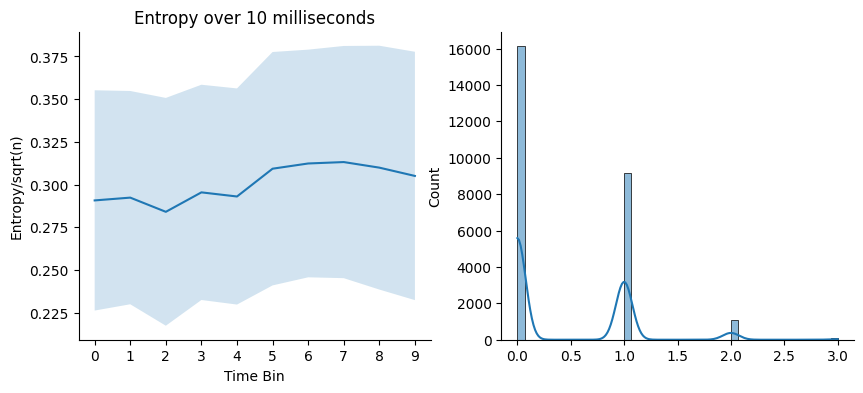

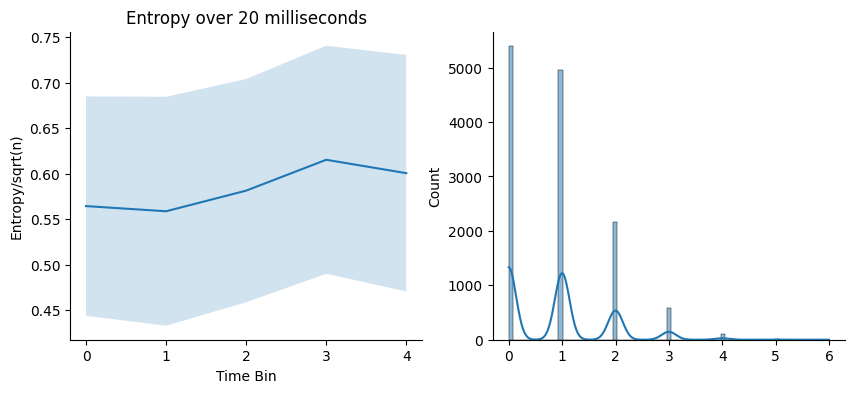

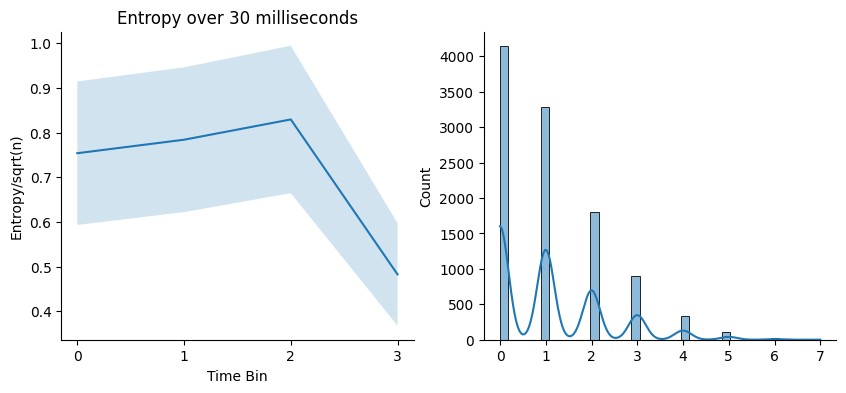

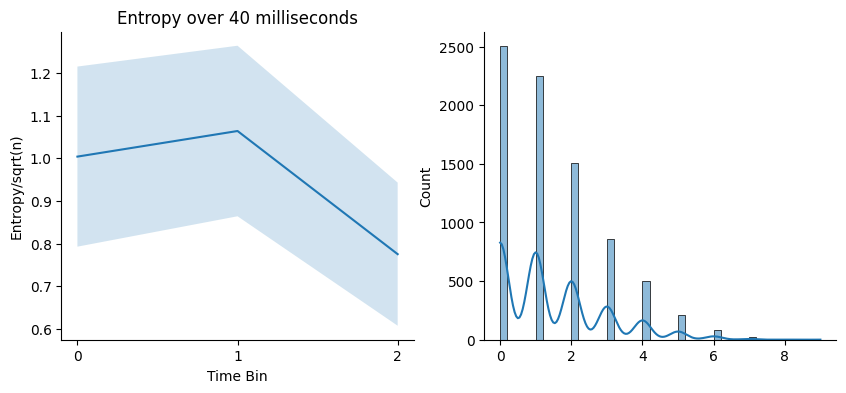

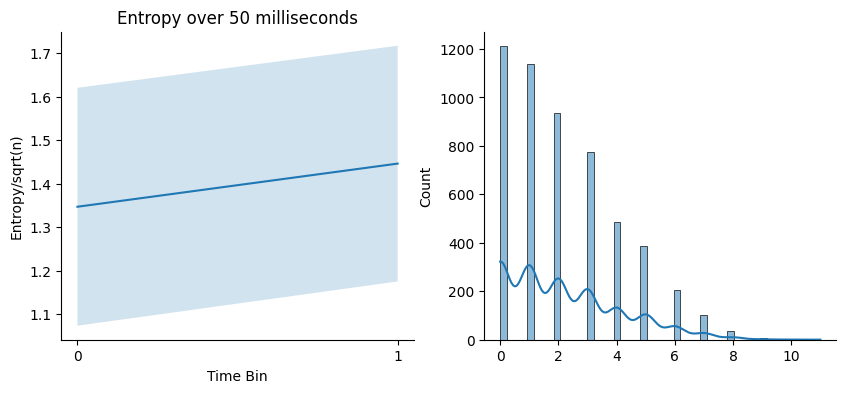

------------



(S3) /Users/kschille/Downloads/ONE/openalyx.internationalbrainlab.org/mrsicflogellab/Subjects/SWC_052/2020-10-21/002/alf/probe01/pykilosort/#2024-05-06#/passingSpikes.table.pqt: 100%|██████████| 161M/161M [00:07<00:00, 22.5MB/s] 
(S3) /Users/kschille/Downloads/ONE/openalyx.internationalbrainlab.org/mrsicflogellab/Subjects/SWC_052/2020-10-21/002/alf/probe01/pykilosort/#2024-05-06#/clusters.channels.npy: 100%|██████████| 9.90k/9.90k [00:00<00:00, 13.1kB/s]
(S3) /Users/kschille/Downloads/ONE/openalyx.internationalbrainlab.org/mrsicflogellab/Subjects/SWC_052/2020-10-21/002/alf/probe01/pykilosort/#2024-05-06#/clusters.depths.npy: 100%|██████████| 5.01k/5.01k [00:00<00:00, 10.8kB/s]
(S3) /Users/kschille/Downloads/ONE/openalyx.internationalbrainlab.org/mrsicflogellab/Subjects/SWC_052/2020-10-21/002/alf/probe01/pykilosort/#2024-05-06#/clusters.metrics.pqt: 100%|██████████| 171k/171k [00:00<00:00, 211kB/s]
(S3) /Users/kschille/Downloads/ONE/openalyx.internationalbrainlab.org/mrsicflogellab/Subj

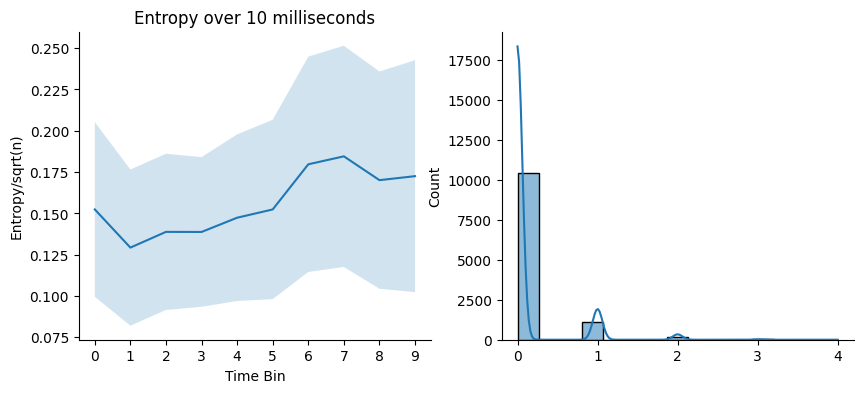

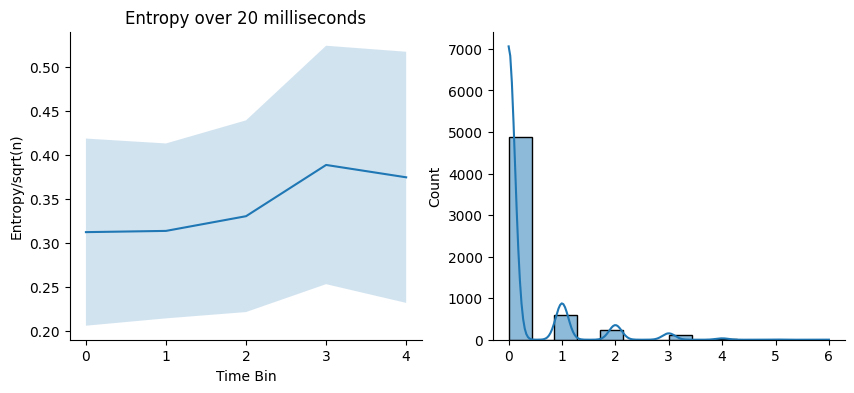

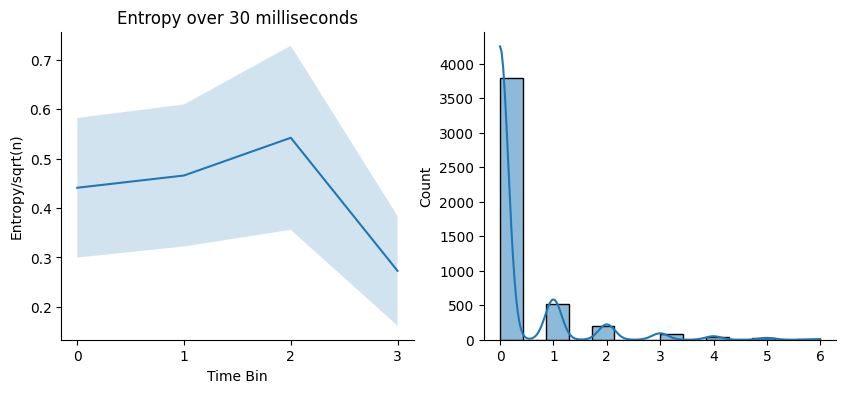

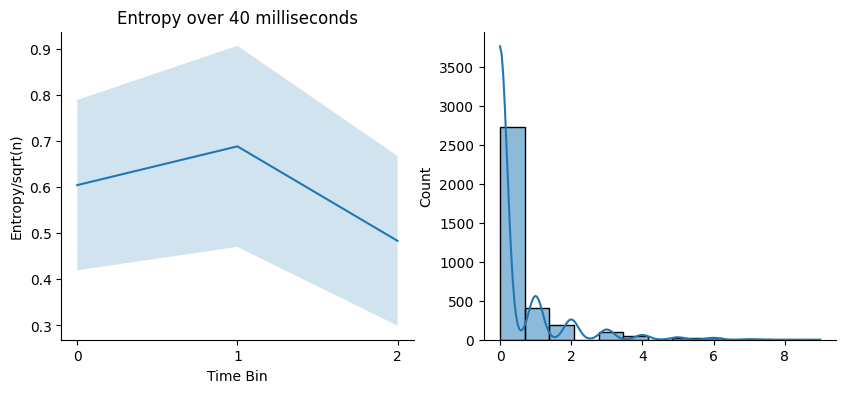

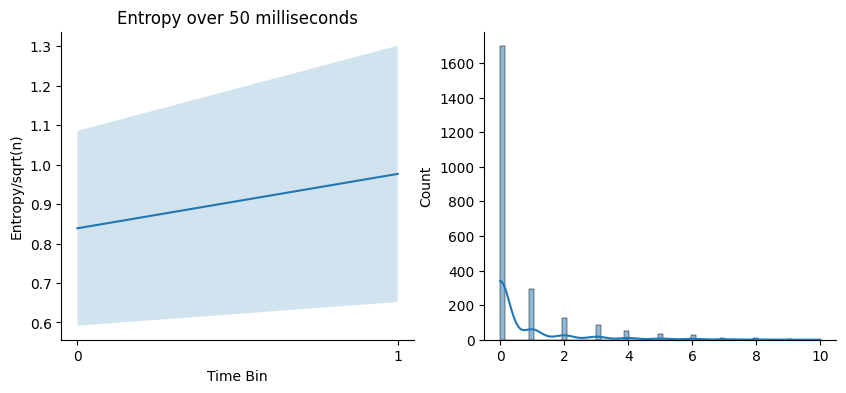

------------



(S3) /Users/kschille/Downloads/ONE/openalyx.internationalbrainlab.org/zadorlab/Subjects/CSH_ZAD_001/2020-01-16/001/alf/probe00/pykilosort/#2024-05-06#/passingSpikes.table.pqt: 100%|██████████| 102M/102M [00:07<00:00, 13.1MB/s] 
(S3) /Users/kschille/Downloads/ONE/openalyx.internationalbrainlab.org/zadorlab/Subjects/CSH_ZAD_001/2020-01-16/001/alf/probe00/pykilosort/#2024-05-06#/clusters.channels.npy: 100%|██████████| 4.28k/4.28k [00:00<00:00, 9.86kB/s]
(S3) /Users/kschille/Downloads/ONE/openalyx.internationalbrainlab.org/zadorlab/Subjects/CSH_ZAD_001/2020-01-16/001/alf/probe00/pykilosort/#2024-05-06#/clusters.depths.npy: 100%|██████████| 2.20k/2.20k [00:00<00:00, 4.07kB/s]
(S3) /Users/kschille/Downloads/ONE/openalyx.internationalbrainlab.org/zadorlab/Subjects/CSH_ZAD_001/2020-01-16/001/alf/probe00/pykilosort/#2024-05-06#/clusters.metrics.pqt: 100%|██████████| 78.5k/78.5k [00:01<00:00, 59.8kB/s]
(S3) /Users/kschille/Downloads/ONE/openalyx.internationalbrainlab.org/zadorlab/Subjects/CSH_ZA

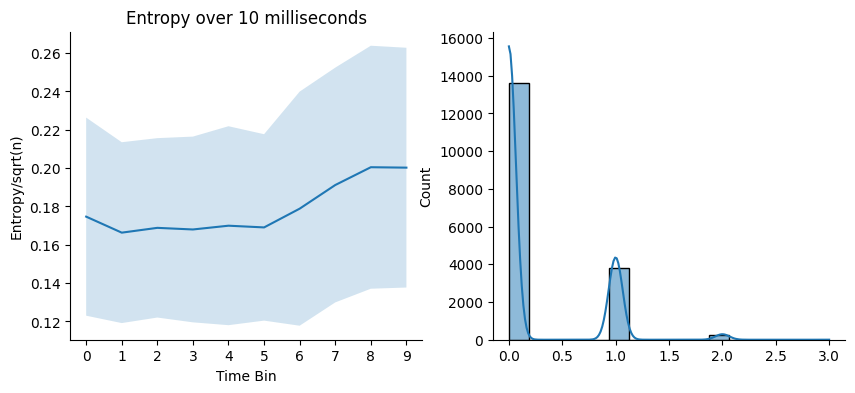

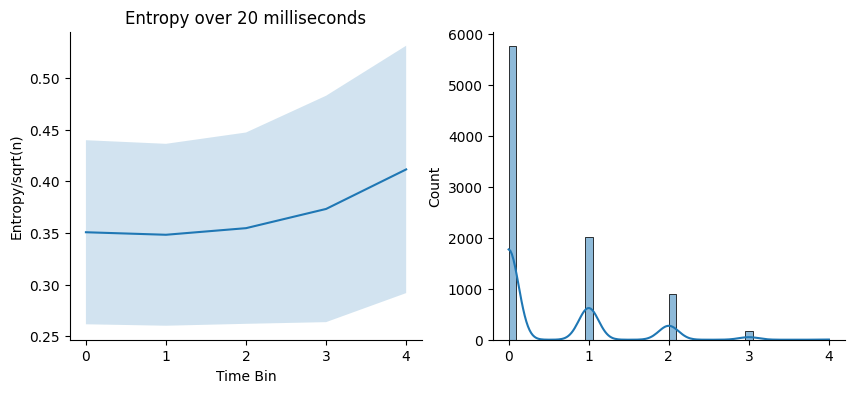

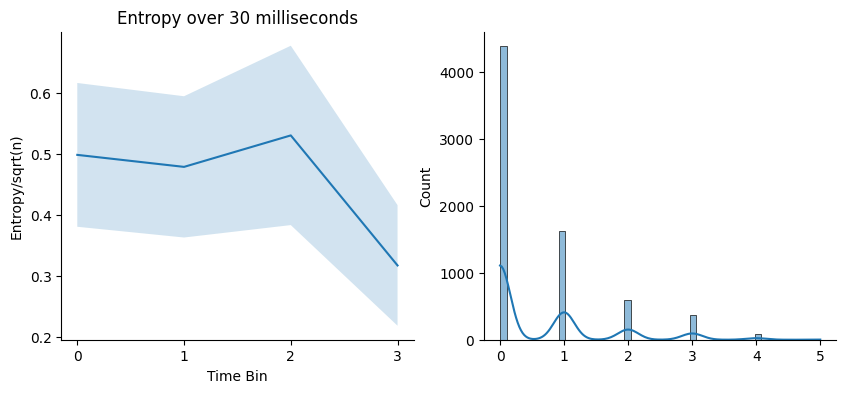

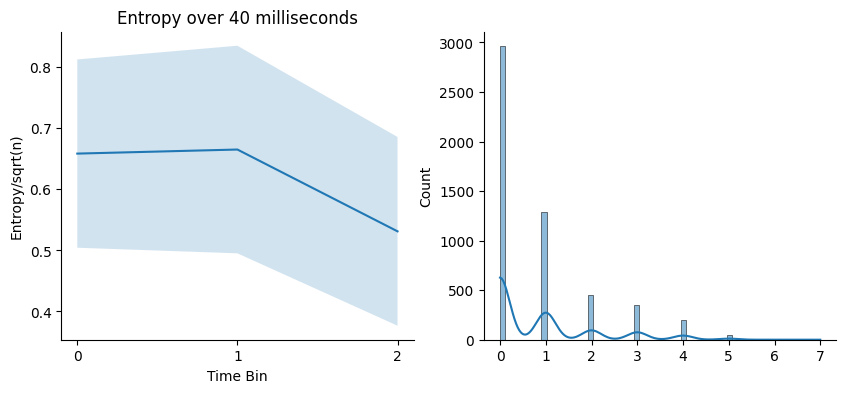

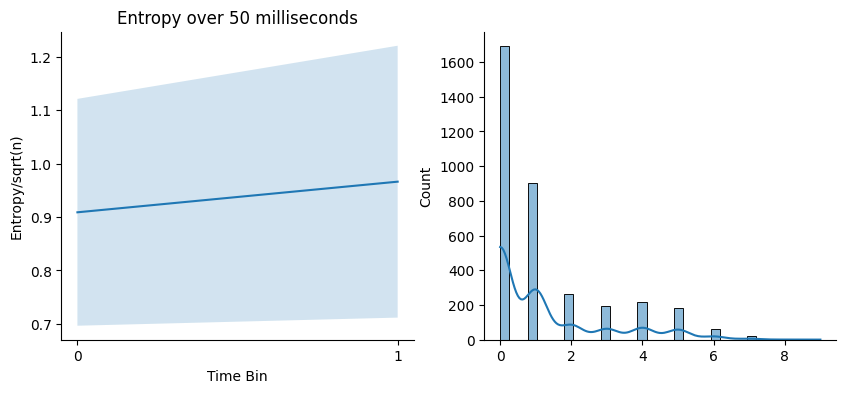

------------



(S3) /Users/kschille/Downloads/ONE/openalyx.internationalbrainlab.org/steinmetzlab/Subjects/NR_0029/2023-08-29/001/alf/probe00a/pykilosort/#2024-05-06#/passingSpikes.table.pqt: 100%|██████████| 36.1M/36.1M [00:05<00:00, 7.21MB/s]
(S3) /Users/kschille/Downloads/ONE/openalyx.internationalbrainlab.org/steinmetzlab/Subjects/NR_0029/2023-08-29/001/alf/probe00a/pykilosort/#2024-05-06#/clusters.channels.npy: 100%|██████████| 1.46k/1.46k [00:00<00:00, 3.29kB/s]
(S3) /Users/kschille/Downloads/ONE/openalyx.internationalbrainlab.org/steinmetzlab/Subjects/NR_0029/2023-08-29/001/alf/probe00a/pykilosort/#2024-05-06#/clusters.depths.npy: 100%|██████████| 796/796 [00:00<00:00, 1.76kB/s]
(S3) /Users/kschille/Downloads/ONE/openalyx.internationalbrainlab.org/steinmetzlab/Subjects/NR_0029/2023-08-29/001/alf/probe00a/pykilosort/#2024-05-06#/clusters.metrics.pqt: 100%|██████████| 35.6k/35.6k [00:00<00:00, 56.3kB/s]
(S3) /Users/kschille/Downloads/ONE/openalyx.internationalbrainlab.org/steinmetzlab/Subjects/N

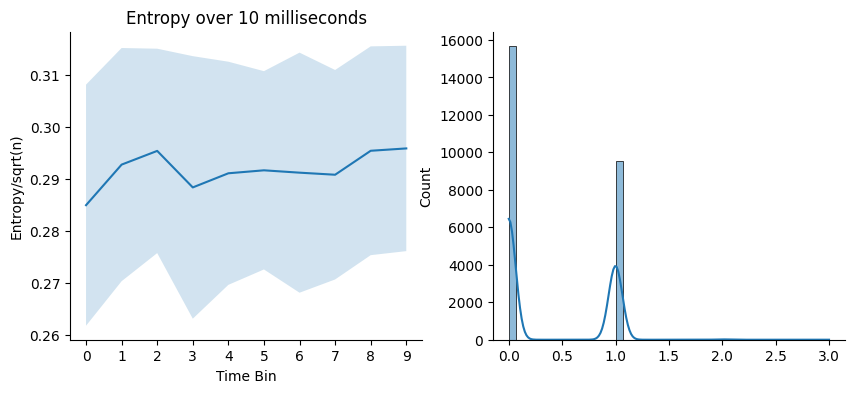

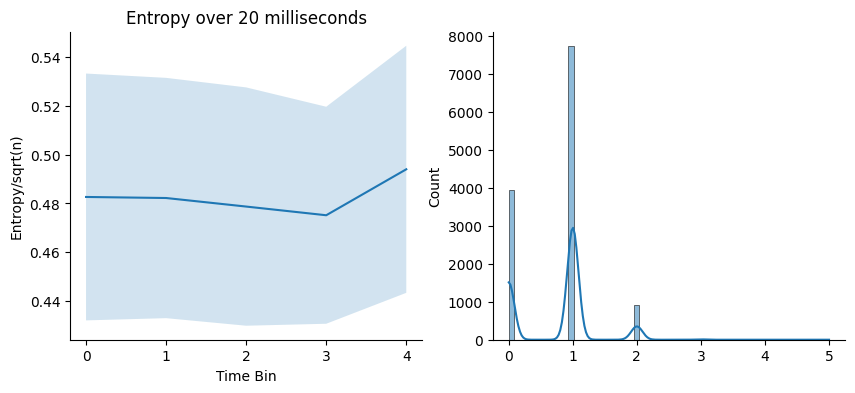

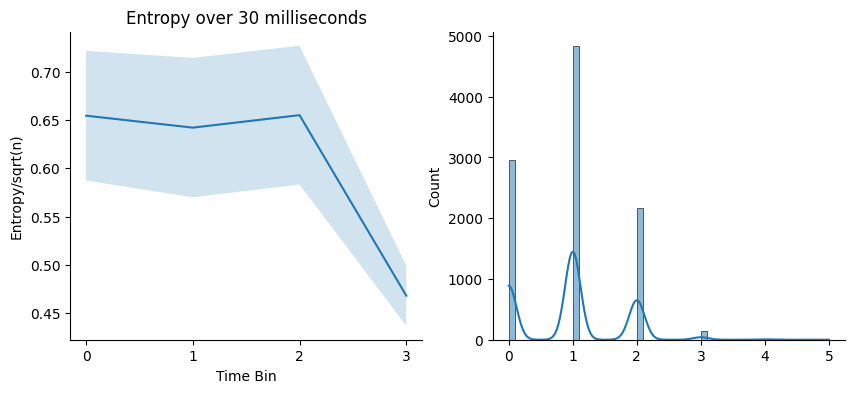

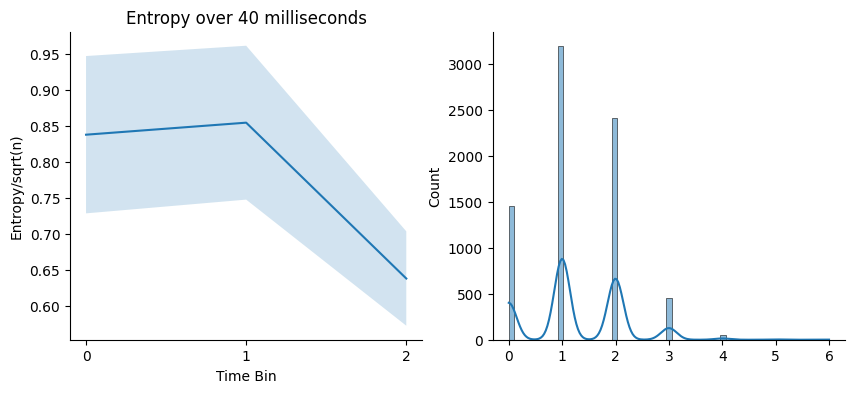

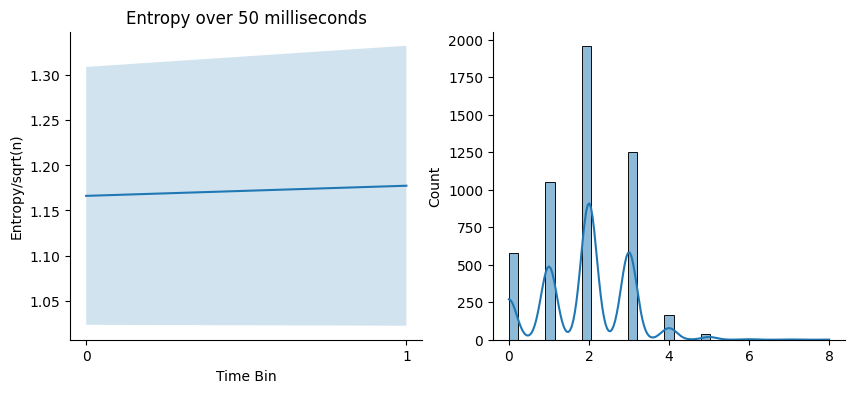

------------



(S3) /Users/kschille/Downloads/ONE/openalyx.internationalbrainlab.org/angelakilab/Subjects/NYU-45/2021-07-19/001/alf/probe01/pykilosort/#2024-05-06#/passingSpikes.table.pqt: 100%|██████████| 360M/360M [00:14<00:00, 24.8MB/s] 
(S3) /Users/kschille/Downloads/ONE/openalyx.internationalbrainlab.org/angelakilab/Subjects/NYU-45/2021-07-19/001/alf/probe01/pykilosort/#2024-05-06#/clusters.channels.npy: 100%|██████████| 4.79k/4.79k [00:00<00:00, 10.9kB/s]
(S3) /Users/kschille/Downloads/ONE/openalyx.internationalbrainlab.org/angelakilab/Subjects/NYU-45/2021-07-19/001/alf/probe01/pykilosort/#2024-05-06#/clusters.depths.npy: 100%|██████████| 2.46k/2.46k [00:00<00:00, 5.61kB/s]
(S3) /Users/kschille/Downloads/ONE/openalyx.internationalbrainlab.org/angelakilab/Subjects/NYU-45/2021-07-19/001/alf/probe01/pykilosort/#2024-05-06#/clusters.metrics.pqt: 100%|██████████| 86.6k/86.6k [00:00<00:00, 133kB/s]
(S3) /Users/kschille/Downloads/ONE/openalyx.internationalbrainlab.org/angelakilab/Subjects/NYU-45/2021-

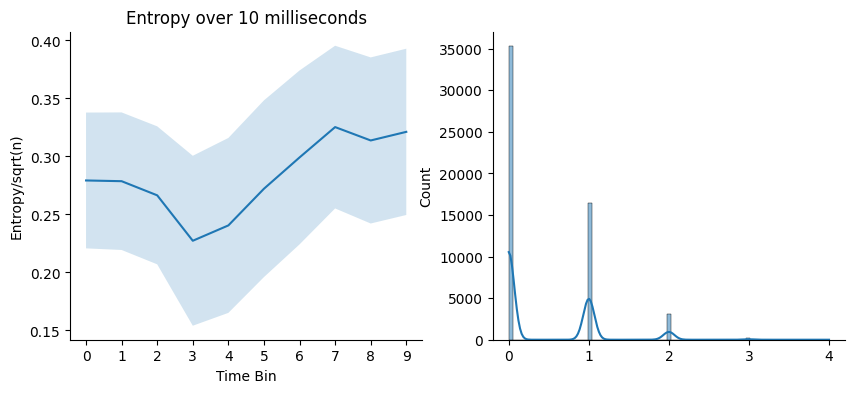

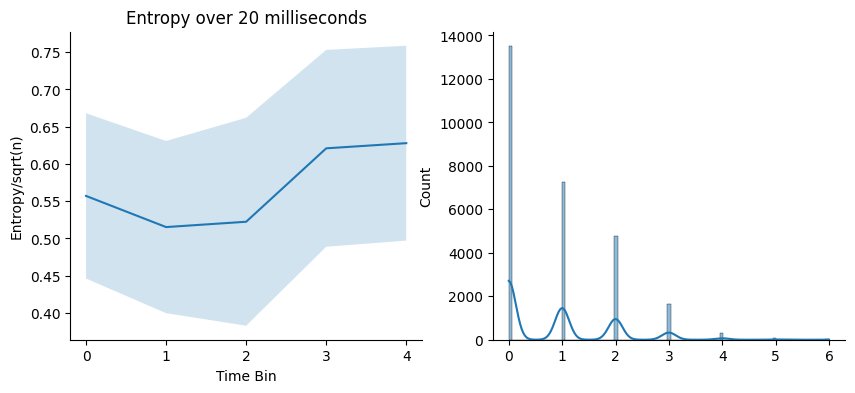

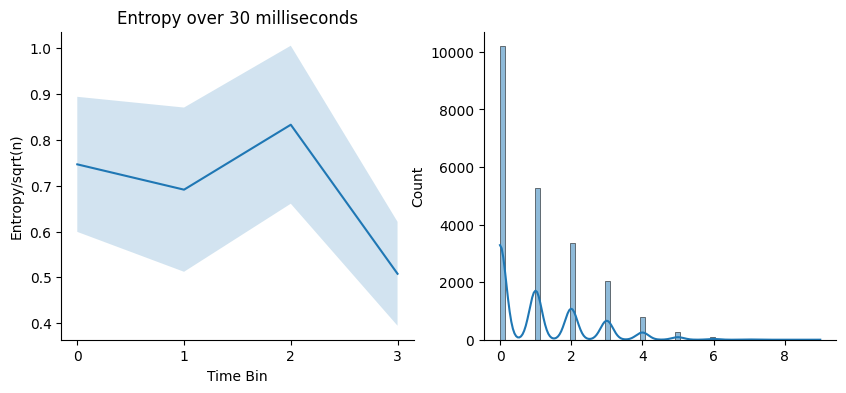

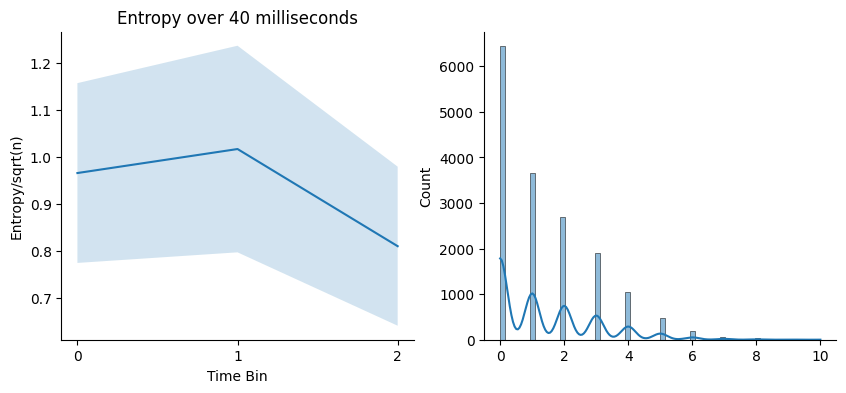

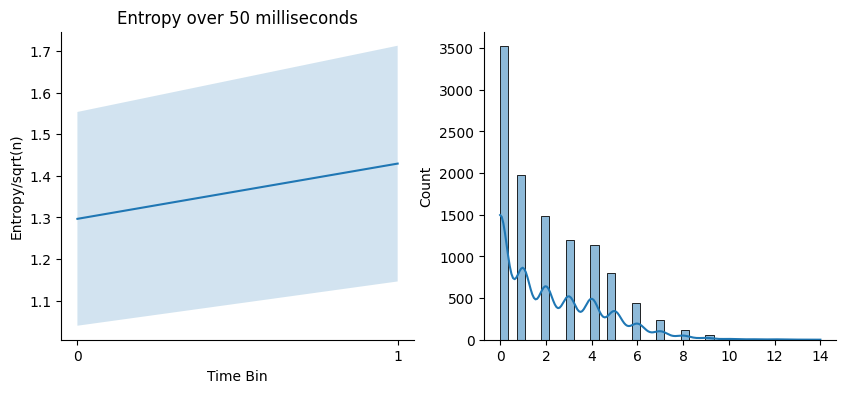

------------



(S3) /Users/kschille/Downloads/ONE/openalyx.internationalbrainlab.org/cortexlab/Subjects/KS016/2019-12-05/001/alf/probe00/pykilosort/#2024-05-06#/passingSpikes.table.pqt: 100%|██████████| 22.7M/22.7M [00:02<00:00, 8.48MB/s]
(S3) /Users/kschille/Downloads/ONE/openalyx.internationalbrainlab.org/cortexlab/Subjects/KS016/2019-12-05/001/alf/probe00/pykilosort/#2024-05-06#/clusters.channels.npy: 100%|██████████| 2.82k/2.82k [00:00<00:00, 6.18kB/s]
(S3) /Users/kschille/Downloads/ONE/openalyx.internationalbrainlab.org/cortexlab/Subjects/KS016/2019-12-05/001/alf/probe00/pykilosort/#2024-05-06#/clusters.depths.npy: 100%|██████████| 1.47k/1.47k [00:00<00:00, 3.43kB/s]
(S3) /Users/kschille/Downloads/ONE/openalyx.internationalbrainlab.org/cortexlab/Subjects/KS016/2019-12-05/001/alf/probe00/pykilosort/#2024-05-06#/clusters.metrics.pqt: 100%|██████████| 55.8k/55.8k [00:00<00:00, 93.5kB/s]
(S3) /Users/kschille/Downloads/ONE/openalyx.internationalbrainlab.org/cortexlab/Subjects/KS016/2019-12-05/001/alf

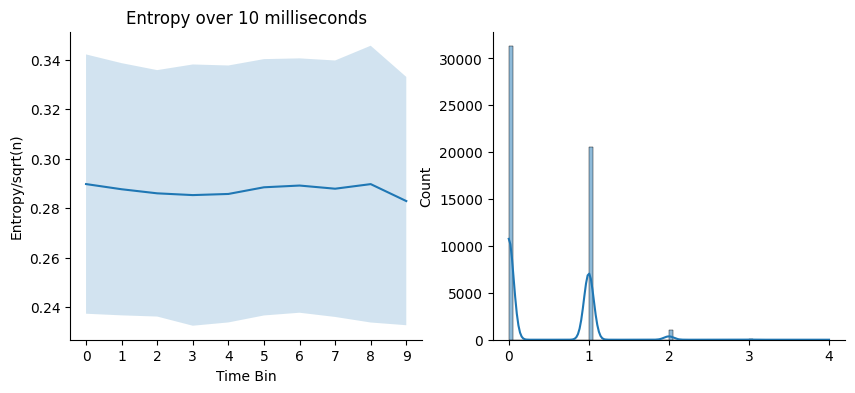

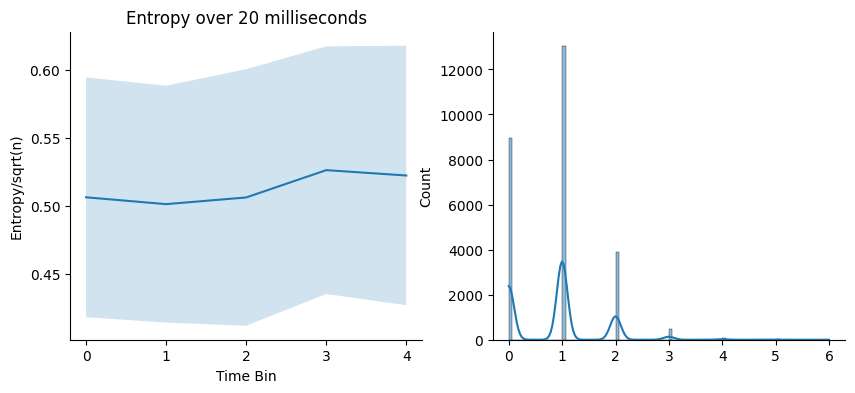

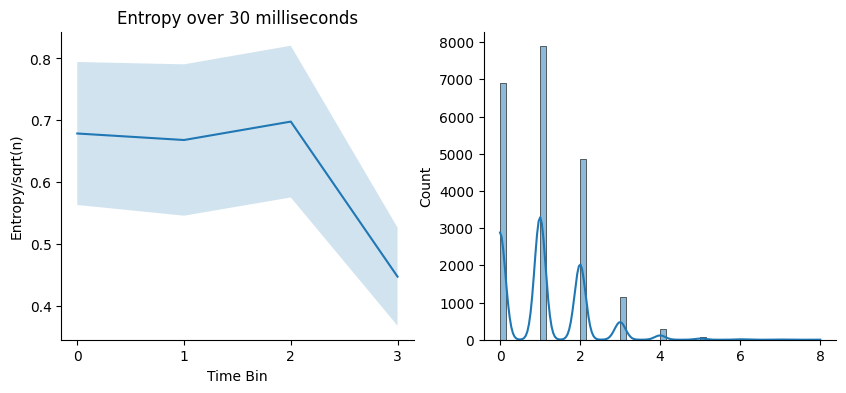

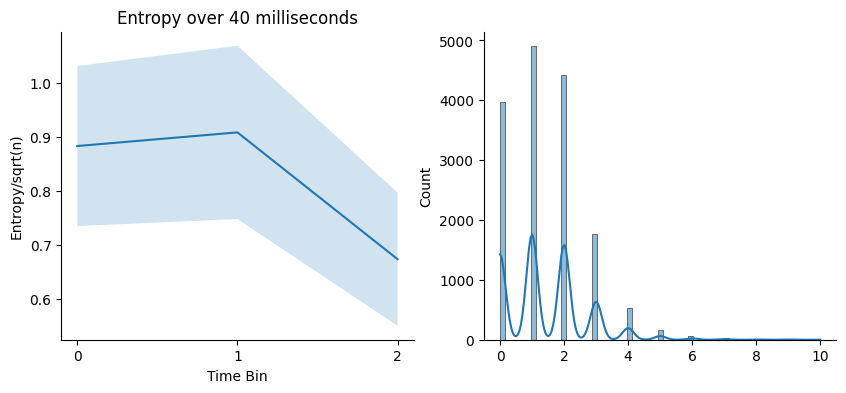

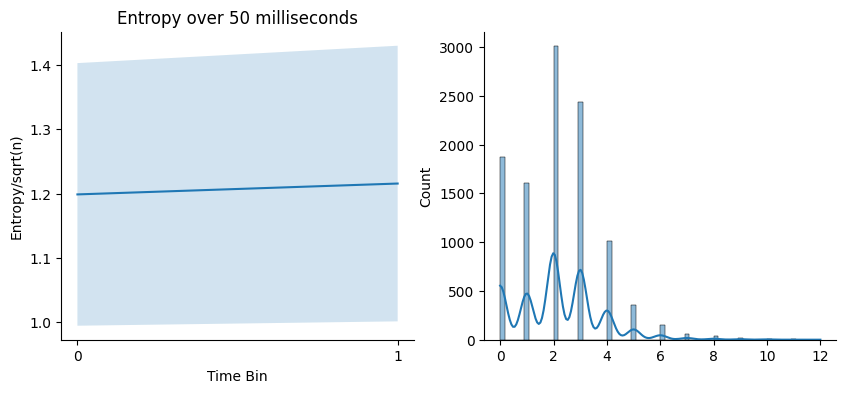

------------



(S3) /Users/kschille/Downloads/ONE/openalyx.internationalbrainlab.org/hausserlab/Subjects/PL031/2022-12-07/001/alf/probe00/pykilosort/#2024-05-06#/passingSpikes.table.pqt: 100%|██████████| 129M/129M [00:09<00:00, 13.7MB/s] 
(S3) /Users/kschille/Downloads/ONE/openalyx.internationalbrainlab.org/hausserlab/Subjects/PL031/2022-12-07/001/alf/probe00/pykilosort/#2024-05-06#/clusters.channels.npy: 100%|██████████| 5.90k/5.90k [00:00<00:00, 13.8kB/s]
(S3) /Users/kschille/Downloads/ONE/openalyx.internationalbrainlab.org/hausserlab/Subjects/PL031/2022-12-07/001/alf/probe00/pykilosort/#2024-05-06#/clusters.depths.npy: 100%|██████████| 3.02k/3.02k [00:00<00:00, 6.06kB/s]
(S3) /Users/kschille/Downloads/ONE/openalyx.internationalbrainlab.org/hausserlab/Subjects/PL031/2022-12-07/001/alf/probe00/pykilosort/#2024-05-06#/clusters.metrics.pqt: 100%|██████████| 104k/104k [00:00<00:00, 154kB/s]
(S3) /Users/kschille/Downloads/ONE/openalyx.internationalbrainlab.org/hausserlab/Subjects/PL031/2022-12-07/001/al

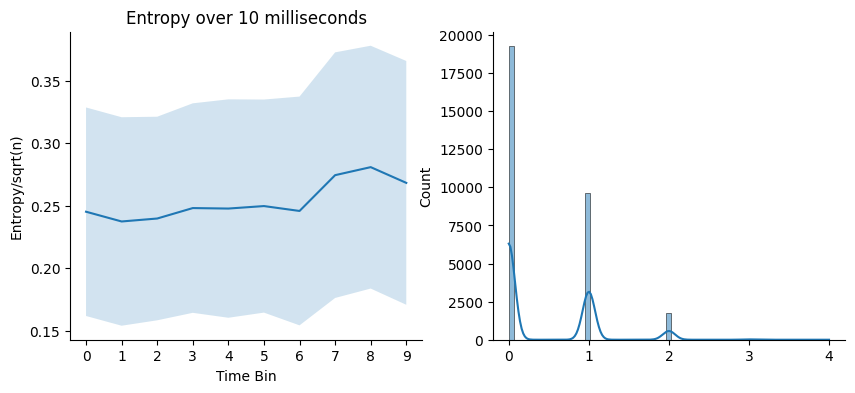

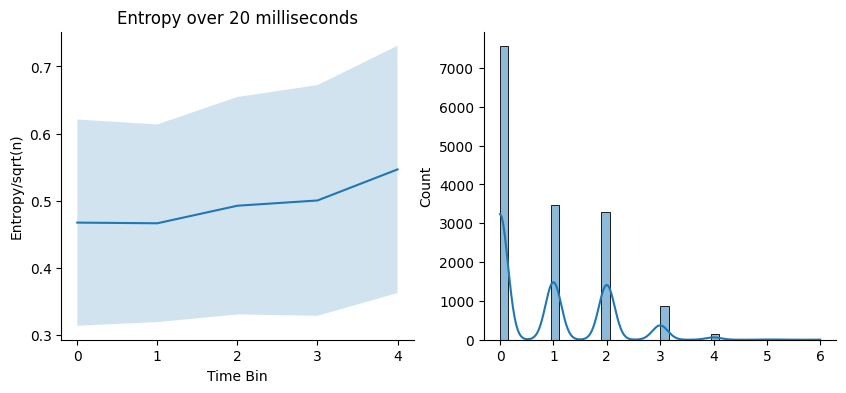

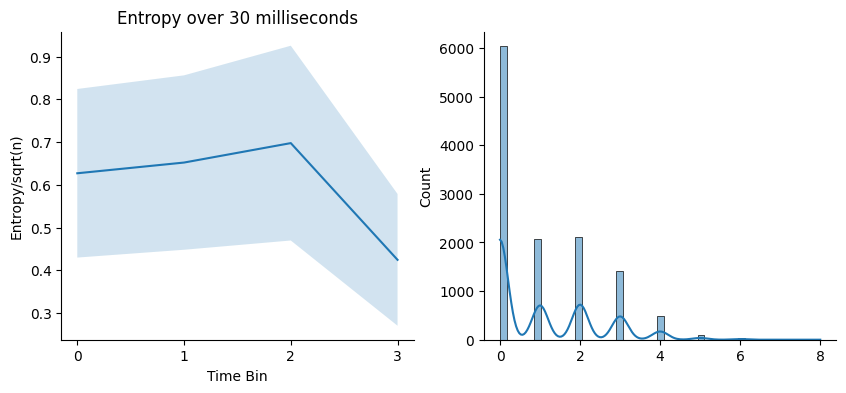

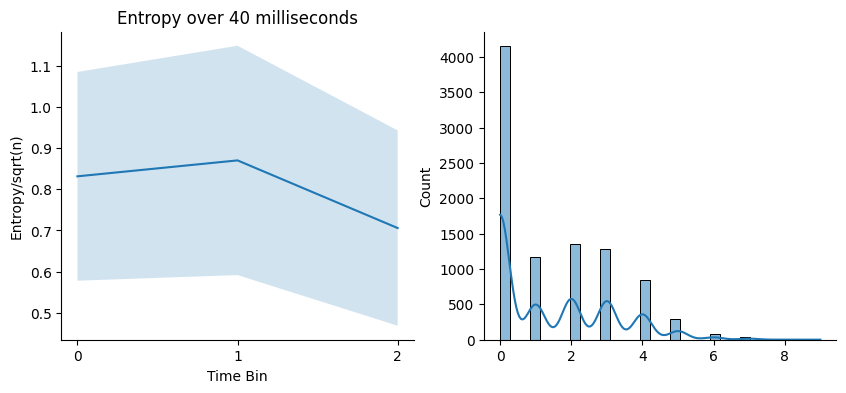

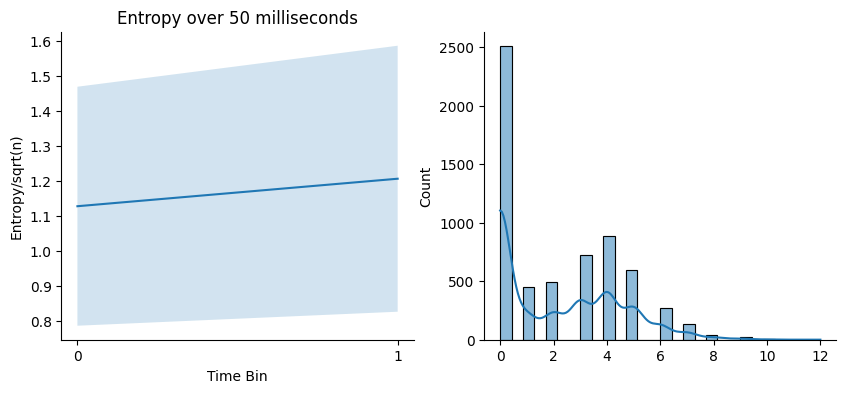

------------



(S3) /Users/kschille/Downloads/ONE/openalyx.internationalbrainlab.org/steinmetzlab/Subjects/NR_0029/2023-08-31/001/alf/probe00b/pykilosort/#2024-05-06#/passingSpikes.table.pqt: 100%|██████████| 51.4M/51.4M [00:04<00:00, 12.3MB/s]
(S3) /Users/kschille/Downloads/ONE/openalyx.internationalbrainlab.org/steinmetzlab/Subjects/NR_0029/2023-08-31/001/alf/probe00b/pykilosort/#2024-05-06#/clusters.channels.npy: 100%|██████████| 2.74k/2.74k [00:00<00:00, 6.07kB/s]
(S3) /Users/kschille/Downloads/ONE/openalyx.internationalbrainlab.org/steinmetzlab/Subjects/NR_0029/2023-08-31/001/alf/probe00b/pykilosort/#2024-05-06#/clusters.depths.npy: 100%|██████████| 1.43k/1.43k [00:00<00:00, 3.04kB/s]
(S3) /Users/kschille/Downloads/ONE/openalyx.internationalbrainlab.org/steinmetzlab/Subjects/NR_0029/2023-08-31/001/alf/probe00b/pykilosort/#2024-05-06#/clusters.metrics.pqt: 100%|██████████| 54.2k/54.2k [00:00<00:00, 87.0kB/s]
(S3) /Users/kschille/Downloads/ONE/openalyx.internationalbrainlab.org/steinmetzlab/Subjec

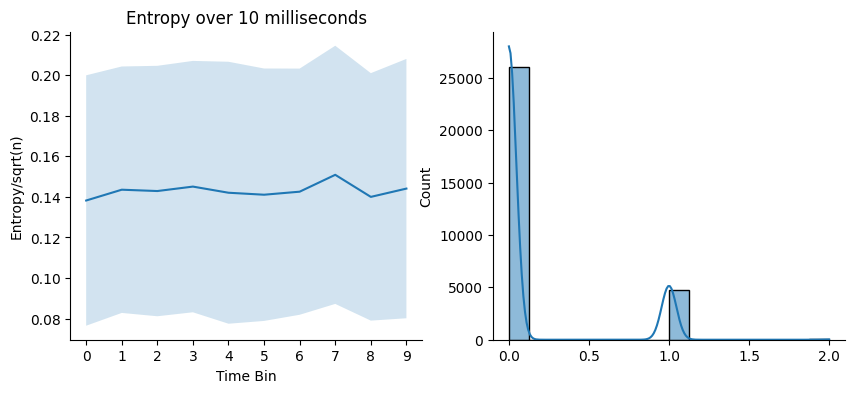

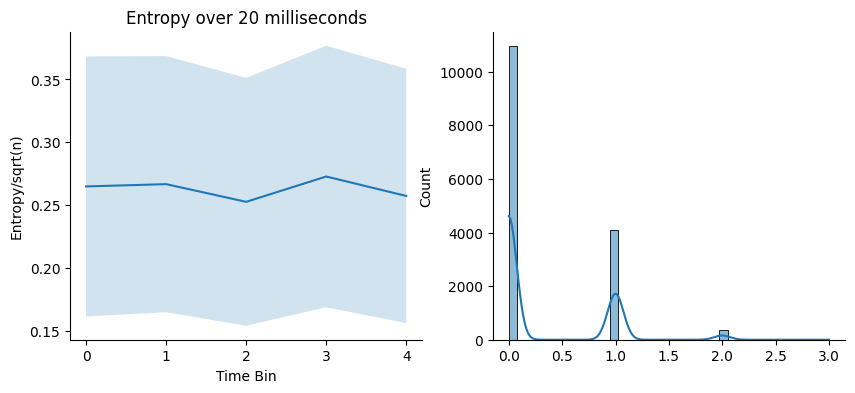

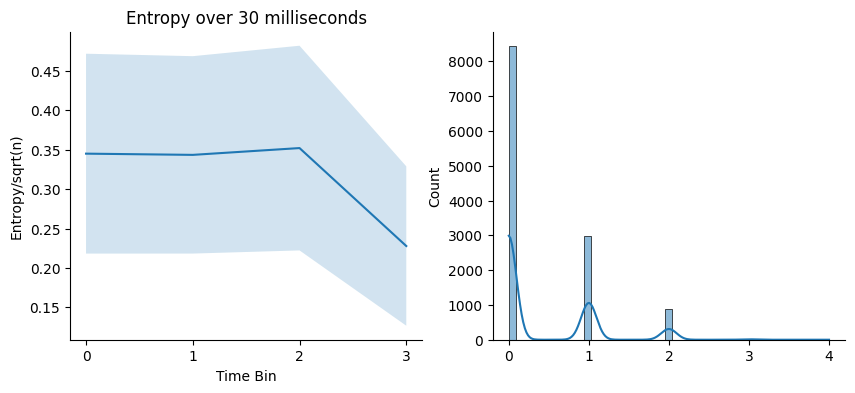

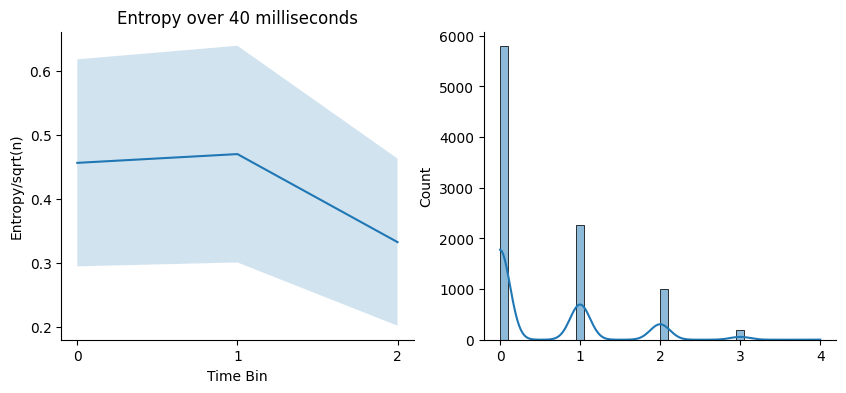

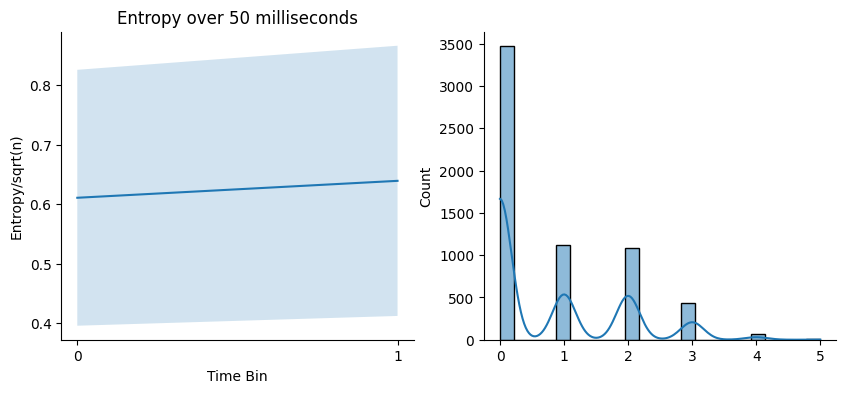

------------



(S3) /Users/kschille/Downloads/ONE/openalyx.internationalbrainlab.org/danlab/Subjects/DY_018/2020-10-17/001/alf/probe00/pykilosort/#2024-05-06#/passingSpikes.table.pqt: 100%|██████████| 158M/158M [00:06<00:00, 23.0MB/s] 
(S3) /Users/kschille/Downloads/ONE/openalyx.internationalbrainlab.org/danlab/Subjects/DY_018/2020-10-17/001/alf/probe00/pykilosort/#2024-05-06#/clusters.channels.npy: 100%|██████████| 6.76k/6.76k [00:00<00:00, 15.3kB/s]
(S3) /Users/kschille/Downloads/ONE/openalyx.internationalbrainlab.org/danlab/Subjects/DY_018/2020-10-17/001/alf/probe00/pykilosort/#2024-05-06#/clusters.depths.npy: 100%|██████████| 3.44k/3.44k [00:00<00:00, 9.76kB/s]
(S3) /Users/kschille/Downloads/ONE/openalyx.internationalbrainlab.org/danlab/Subjects/DY_018/2020-10-17/001/alf/probe00/pykilosort/#2024-05-06#/clusters.metrics.pqt: 100%|██████████| 116k/116k [00:00<00:00, 175kB/s]
(S3) /Users/kschille/Downloads/ONE/openalyx.internationalbrainlab.org/danlab/Subjects/DY_018/2020-10-17/001/alf/probe00/pykil

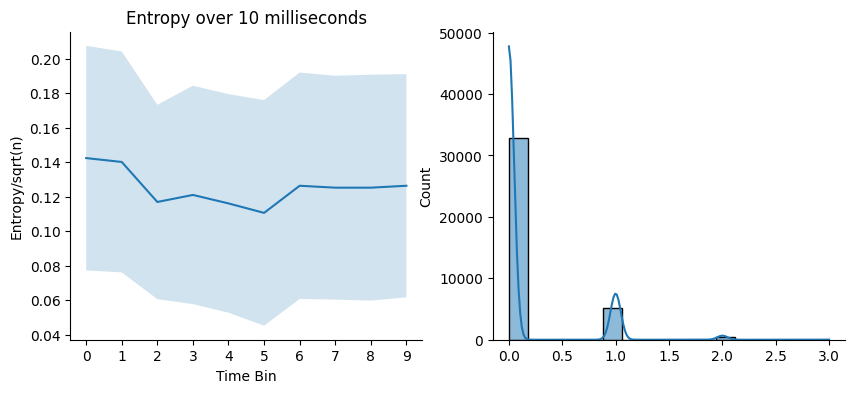

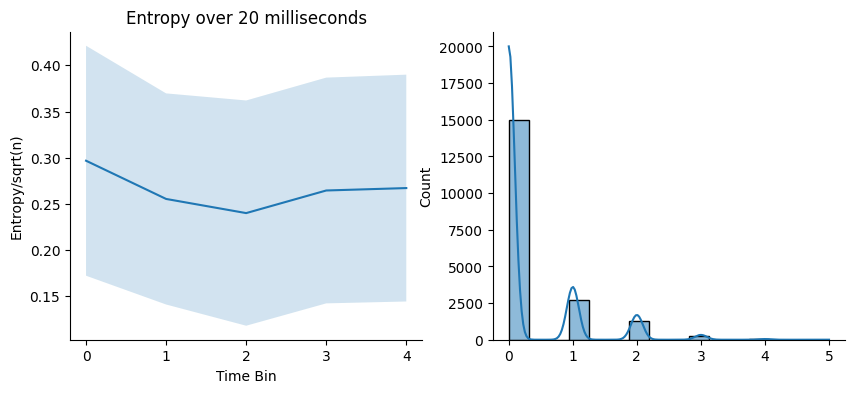

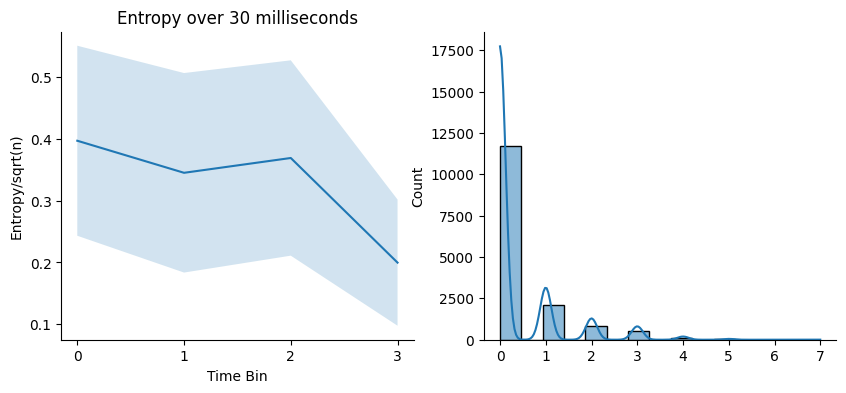

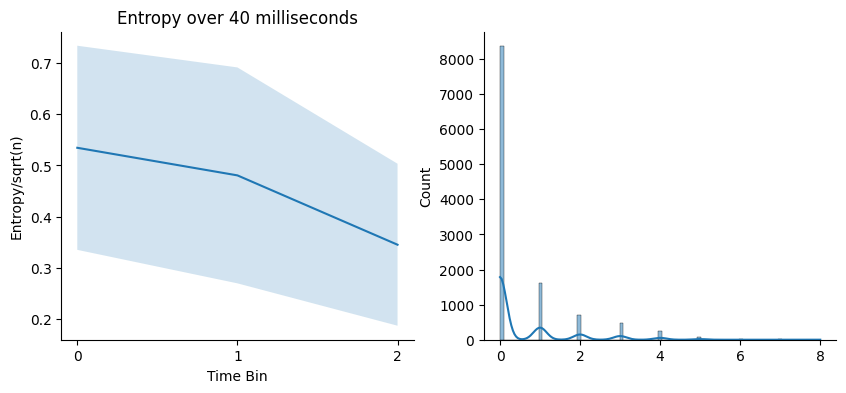

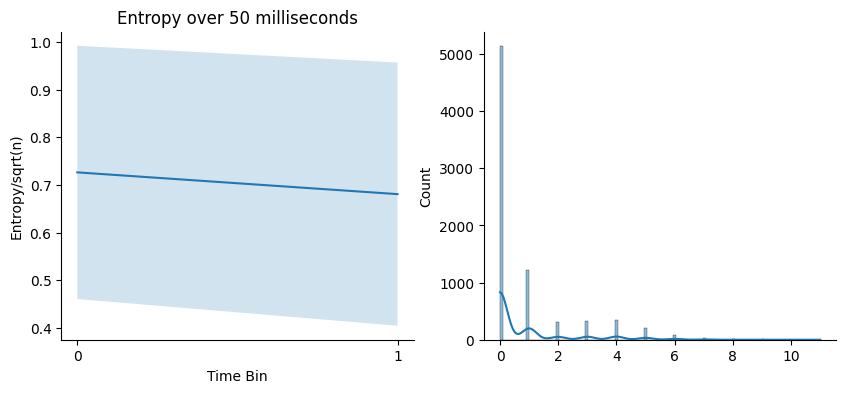

------------



(S3) /Users/kschille/Downloads/ONE/openalyx.internationalbrainlab.org/hausserlab/Subjects/PL017/2021-11-15/001/alf/probe00/pykilosort/#2024-05-06#/passingSpikes.table.pqt: 100%|██████████| 108M/108M [00:04<00:00, 24.7MB/s] 
(S3) /Users/kschille/Downloads/ONE/openalyx.internationalbrainlab.org/hausserlab/Subjects/PL017/2021-11-15/001/alf/probe00/pykilosort/#2024-05-06#/clusters.channels.npy: 100%|██████████| 6.23k/6.23k [00:00<00:00, 15.1kB/s]
(S3) /Users/kschille/Downloads/ONE/openalyx.internationalbrainlab.org/hausserlab/Subjects/PL017/2021-11-15/001/alf/probe00/pykilosort/#2024-05-06#/clusters.depths.npy: 100%|██████████| 3.18k/3.18k [00:00<00:00, 7.08kB/s]
(S3) /Users/kschille/Downloads/ONE/openalyx.internationalbrainlab.org/hausserlab/Subjects/PL017/2021-11-15/001/alf/probe00/pykilosort/#2024-05-06#/clusters.metrics.pqt: 100%|██████████| 108k/108k [00:00<00:00, 144kB/s]
(S3) /Users/kschille/Downloads/ONE/openalyx.internationalbrainlab.org/hausserlab/Subjects/PL017/2021-11-15/001/al

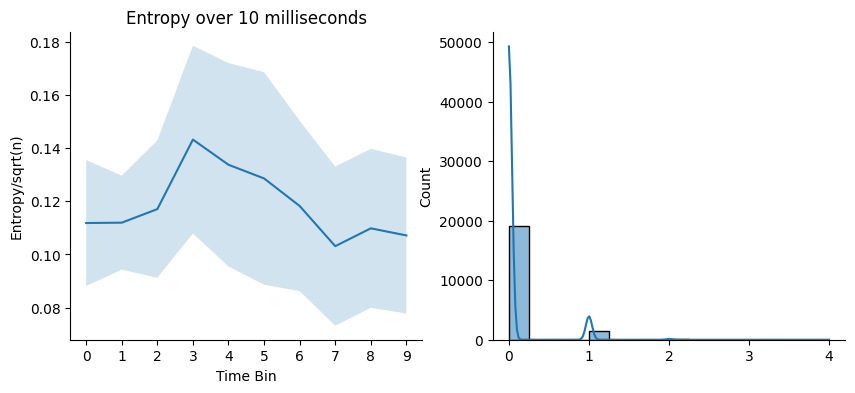

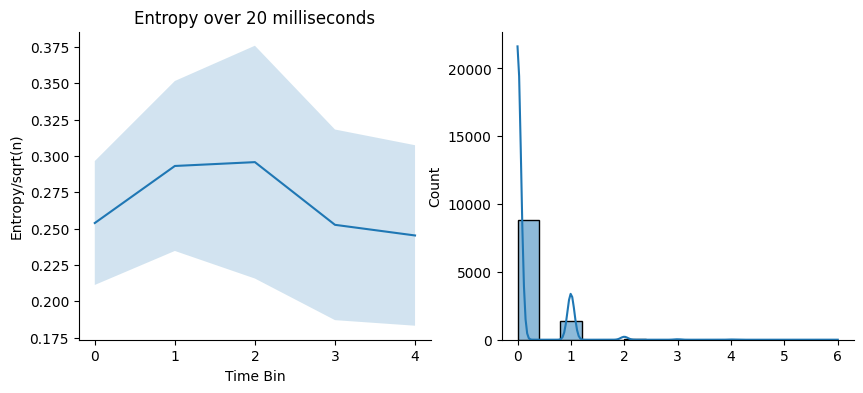

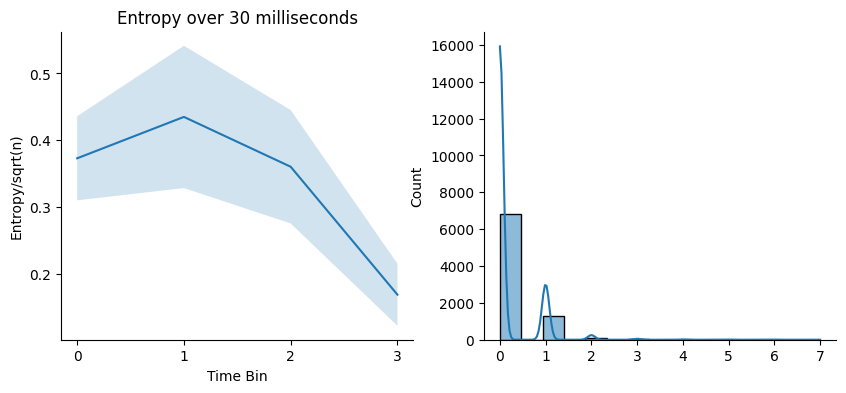

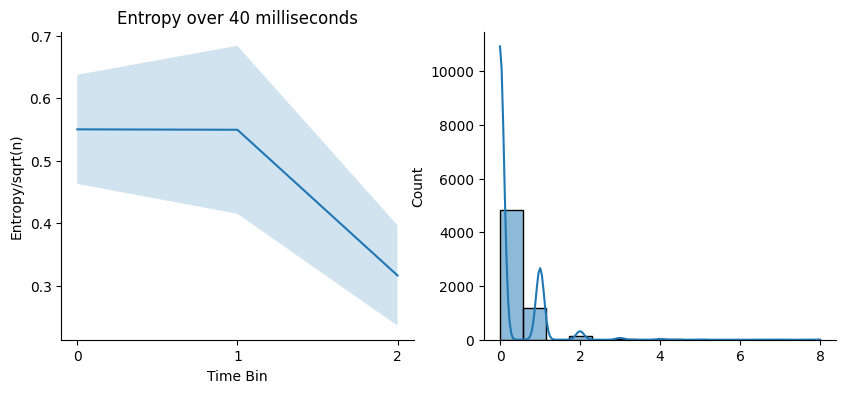

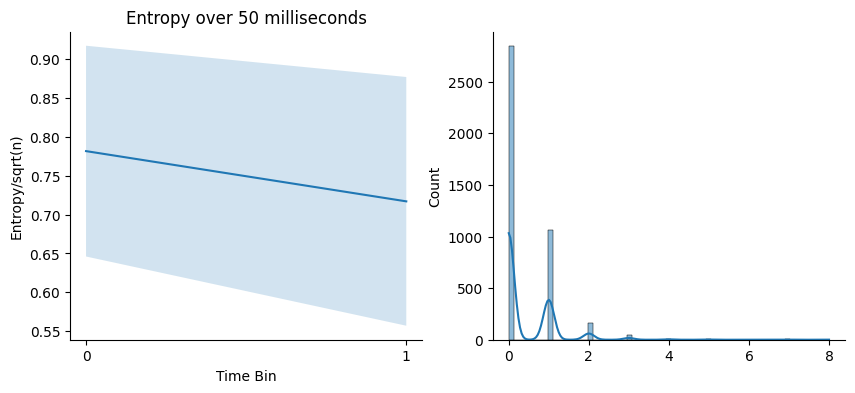

------------



In [10]:
for idx in range(10):
    session_id = selective_eids[idx]
    do_it_for_pid(session_id, True)
    print("------------\n")